<img src="images/utfsm.png" alt="" width="150px" align="left"/>
<img src="images/utfsm.png" alt="" width="150px" align="right"/>
<br/>
<div align="center">
<h2>IPD-434 Seminario de Soft Computing</h2><br/>
<h1>Sistemas Difusos (Fuzzy Systems)</h1>
<br/><br/>
Dr. Nicolás Gálvez Ramírez<br/>
Dr. Patricio Olivares Roncagliolo<br/><br/>
Ingeniería Civil Telemática<br/>
Departamento de Eléctronica<br/>
Universidad Técnica Federico Santa María
</div>

# Conjuntos difusos - Fuzzy Set

- Los conjuntos difusos corresponde a una **generalización** de los conjuntos clásicos.
- Resumen de la Teoría de Conjuntos clásica en el [Anexo](#anexo).

# Membresía en un conjunto

## Función de membresía

- Considere un elemento $x$ y un conjunto $S$.
- Se define la membresía $x$ en $S$ como $\mu_{S}(x)$ de la siguiente manera:
$$
    \mu_{S}(x) = \begin{cases}
      1, & \text{if } x \in S \\
      0, & \text{if } x \notin S
    \end{cases}
$$
- Ej: 
$$A = \{\text{piedra}, \text{papel}, \text{papel}\}$$

$$\mu_{A}(\text{piedra}) = 1$$
$$\mu_{A}(\text{spock}) = 0$$


Considere los siguientes conjuntos

$$ U = \{\text{72 años }, \text{63 años }, \text{41 años }, \text{38 años }, \text{13 años }, \text{15 años }, \text{52 años }\} $$
$$ A = \{ x \mid x \text{ es anciano } \} $$


Comprobando algunos elementos del conjunto $U$ en la función de membresía $\mu_{A}(x)$

- 72 años se pede considerar anciano con seguridad, por lo tanto 
$$ \mu_{A}(\text{72 años}) = 1 $$
<br>
- 13 años se puede considerar que no es anciano con seguridad, por lo tanto 
$$ \mu_{A}(\text{13 años}) = 0 $$

Sin embargo, ¿qué ocurre en otros casos?

$$ \mu_{A}(\text{63 años}) = \text{ ?}$$
$$ \mu_{A}(\text{41 años}) = \text{ ?}$$
$$ \mu_{A}(\text{52 años}) = \text{ ?}$$

Depende de cómo se define la **pertenencia** al conjunto anciano, lo cual no está **claramente** definido. Para estos casos, es conveniente expresar esta incertidumbre en la función de membresía.

Consideremos la siguiente función de membresía para el conjunto $A$:


$$
    \mu_{A}(x) = \begin{cases}
      0, & \text{if } x < 30 \\
      \frac{x-30}{40}, & \text{if } 30 \leq x < 70 \\
      1, & \text{if } x \geq 70 \\
    \end{cases}
$$

Donde $x$ representa la edad. Aplicando dicha función a los elementos en $U$:

$$ \mu_{A}(\text{72 años}) = 1.0 $$
$$ \mu_{A}(\text{63 años}) = 0.825 $$
$$ \mu_{A}(\text{41 años}) = 0.275 $$
$$ \mu_{A}(\text{38 años}) = 0.2 $$
$$ \mu_{A}(\text{13 años}) = 0.0 $$
$$ \mu_{A}(\text{15 años}) = 0.0 $$
$$ \mu_{A}(\text{52 años}) = 0.55 $$

A continuación se muestra un gráfico de la función $\mu_{A}(x)$

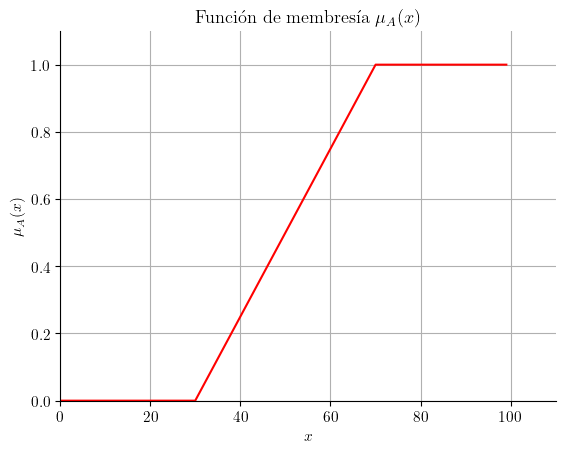

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['text.usetex'] = True
x = np.arange(0,100,1)
y1 = x[0:30]*0
y2 = (x[30:70]-30)/40
y3 = x[70:]*0 + 1
y = np.concatenate([y1, y2, y3])

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.set_title(r'Función de membresía $\mu_{A}(x)$')
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\mu_{A}(x)$")
ax.set_ylim(ymin=-0.1, ymax=1.1)
ax.set_ylim(bottom=0)
ax.set_xlim(xmin=-10, xmax=110)
ax.set_xlim(left=0)
ax.spines[['right', 'top']].set_visible(False)
ax.plot(x, y, 'r')
plt.grid()
plt.show()

Para enumerar los elementos pertenecientes al conjunto $A$, se debe incluir el valor de su función de membresía.

$$ B = \{(\text{72 años}, 1.0), (\text{63 años}, 0.825), (\text{41 años}, 0.275), (\text{38 años}, 0.2), (\text{52 años}, 0.55) \} $$

- *No se agregan aquellos elementos con valor 0*

# Conjuntos difusos (Fuzzy sets)

- Agregan el concepto de **incerteza e imprecisión** a los conjuntos tradicionales.
- **Definición Formal**: Se define $F$ como conjunto difuso dentro de un conjunto universo $U$ como la colleción de pares ordenados $(x, \mu_{F}(x)$ donde $x \in U$ y $\forall x \in U, 0.0 \leq \mu_{F}(x) \leq 1.0$.

$$ F = \{ (x, \mu_{F}(x)) \mid x \in U, 0.0 \leq \mu_{F}(x) \leq 1.0 \} $$
- Cada par $(x, \mu_{F}(x))$ se conoce como **singleton**.

# Notación de conjuntos difusos

- Además de enumerar singletons, los conjuntos difusos también se expresan con la siguiente notación

$$ F = \sum_{x \in U} \frac{\mu_{F}(x)}{x}$$

donde $\sum$ representa unión de singletons, no suma aritmética.

- En conjuntos continuos, se reemplaza el símbolo de sumatoria con la integral

$$ F = \int_{U} \frac{\mu_{F}(x)}{x}$$

# Características de conjuntos difusos

- **Normalidad**: $F$ es normal si al menos un elemento pertenece completamente a $F$ 

$$\exists x \, | \, \mu_{F}(x) = 1.0$$

- **Altura**: 

$$ \text{height}(F) = \max_{x \in U} \mu_{F}(x)$$

$F$ es normal si $\text{height}(F)=1.0$.

- **Soporte**:

$$\text{supp}(F) = \{x \mid x \in U, \mu_{F}(x)>0\}$$

- **Núcleo**: 

$$ \text{core}(F)=\{ x \mid x \in U, \mu_{F}(x)=1 \}$$
$$ \text{core}(F) \subseteq \text{supp}(F)$$

*El soporte y el núcleo corresponden a conjuntos tradicionales (clásicos)*

- **Cardinalidad**: Suma de los valores de membresía

$$ |F| = \sum_{x \in U}\mu_{F}(x)$$

donde $\sum$ sí representa la suma aritmética de los valores $\mu_{F}(x)$

# Funciones de membresía

- Una función de membresía puede ser cualquier función del tipo 

$$\mu_{F} \mid U \rightarrow [0,1]$$

## Funciones de membresía frecuentes

### Función triangular

$$
    \mu(x) = \begin{cases}
      0, & \text{if } x < a \\
      \frac{x-a}{m-a}, & \text{if } a \leq x < m \\
      \frac{b-x}{b-m}, & \text{if } m \leq x < b \\
      1, & \text{if } x \geq b \\
    \end{cases}
$$

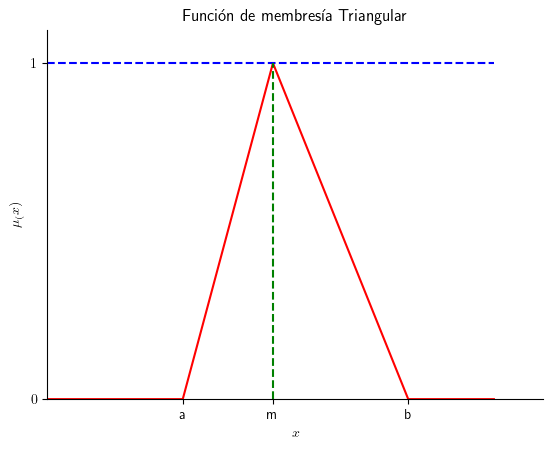

In [21]:
import matplotlib.pyplot as plt
import numpy as np

a = 30
m = 50
b = 80

plt.rcParams['text.usetex'] = True
x = np.arange(0,100,1)
y1 = x[:a]*0
y2 = (x[a:m]-a)/(m-a)
y3 = (b-x[m:b])/(b-m)
y4 = x[b:]*0 
y = np.concatenate([y1, y2, y3, y4])
line_1 = np.ones(len(x))
y_m = np.linspace(0,1,len(x))
line_m = np.ones(len(x))*m


fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.set_title(r'Función de membresía Triangular')
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\mu_(x)$")
ax.set_ylim(ymin=-0.1, ymax=1.1)
ax.set_ylim(bottom=0)
ax.set_xlim(xmin=-10, xmax=110)
ax.set_xlim(left=0)
ax.set_xticks([a,m,b])
ax.set_xticklabels(['a', 'm', 'b'])
ax.set_yticks([0.0, 1.0])
ax.spines[['right', 'top']].set_visible(False)
ax.plot(x, y, 'r', x, line_1, 'b--', line_m, y_m, 'g--')
plt.show()

### Función trapezoidal

$$
    \mu(x) = \begin{cases}
      0, & \text{if } x < a \\
      \frac{x-a}{m-a}, & \text{if } a \leq x < m \\
      1, & \text{if } m \leq x < n \\
      \frac{b-x}{b-n}, & \text{if } n \leq x < b \\
      1, & \text{if } x \geq b \\
    \end{cases}
$$

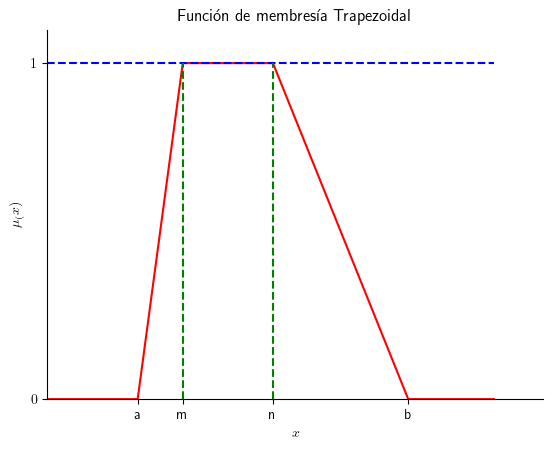

In [24]:
import matplotlib.pyplot as plt
import numpy as np

a = 20
m = 30
n = 50
b = 80

plt.rcParams['text.usetex'] = True
x = np.arange(0,100,1)
y1 = x[:a]*0
y2 = (x[a:m]-a)/(m-a)
y3 = np.ones(n-m)
y4 = (b-x[n:b])/(b-n)
y5 = x[b:]*0 
y = np.concatenate([y1, y2, y3, y4, y5])
line_1 = np.ones(len(x))
y_m = np.linspace(0,1,len(x))
line_m = np.ones(len(x))*m
y_n = np.linspace(0,1,len(x))
line_n = np.ones(len(x))*n


fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.set_title(r'Función de membresía Trapezoidal')
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\mu_(x)$")
ax.set_ylim(ymin=-0.1, ymax=1.1)
ax.set_ylim(bottom=0)
ax.set_xlim(xmin=-10, xmax=110)
ax.set_xlim(left=0)
ax.set_xticks([a, m, n, b])
ax.set_xticklabels(['a', 'm', 'n', 'b'])
ax.set_yticks([0.0, 1.0])
ax.spines[['right', 'top']].set_visible(False)
ax.plot(x, y, 'r', x, line_1, 'b--', line_m, y_m, 'g--', line_n, y_n, 'g--')
plt.show()

### Función Gaussiana

$$ \mu(x) = e^{-k(x-m)^2} \text{ where } k > 0 $$

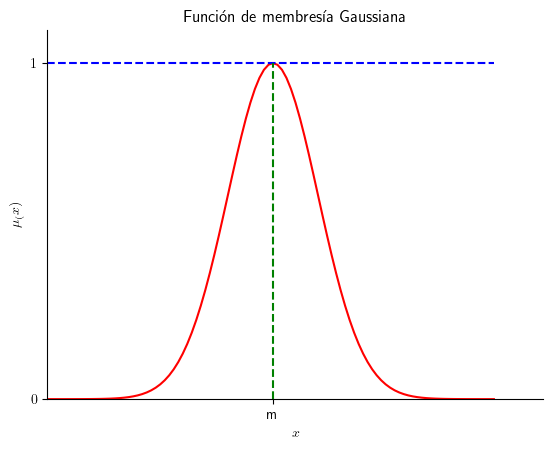

In [38]:
import matplotlib.pyplot as plt
import numpy as np

m = 50
k = 0.005

plt.rcParams['text.usetex'] = True
x = np.arange(0,100,1)
y = np.exp(-k*(x-m)**2)
line_m = np.ones(len(x))*m
line_1 = np.ones(len(x))

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.set_title(r'Función de membresía Gaussiana')
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\mu_(x)$")
ax.set_ylim(ymin=-0.1, ymax=1.1)
ax.set_ylim(bottom=0)
ax.set_xlim(xmin=-10, xmax=110)
ax.set_xlim(left=0)
ax.set_xticks([m])
ax.set_xticklabels(['m'])
ax.set_yticks([0.0, 1.0])
ax.spines[['right', 'top']].set_visible(False)
ax.plot(x, y, 'r', x, line_1, 'b--', line_m, y_m, 'g--')
plt.show()

### Función-S

$$
    \mu(x) = \begin{cases}
      0, & \text{if } x < a \\
      2 \Bigl( \frac{x-a}{b-a} \Bigr)^2, & \text{if } a \leq x < m \\
      1 - 2 \Bigl( \frac{x-b}{b-a} \Bigr)^2, & \text{if } m \leq x < b \\
      1, & \text{if } x \geq b \\
    \end{cases}
$$

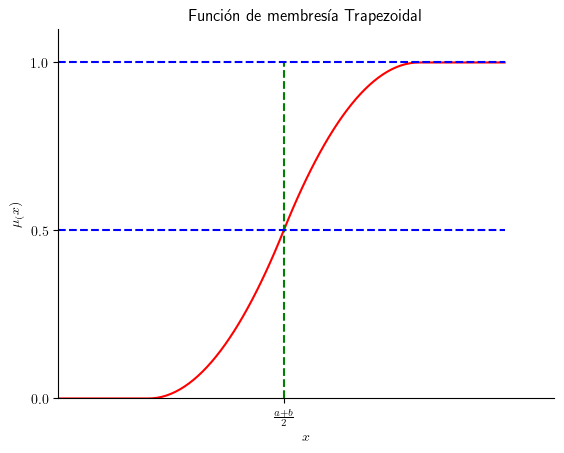

In [51]:
import matplotlib.pyplot as plt
import numpy as np

a = 20
b = 80
m = int((a+b)/2)

plt.rcParams['text.usetex'] = True
x = np.arange(0,100,1)
y1 = x[:a]*0
y2 = 2*(((x[a:m]-a)/(b-a))**2)
y3 = 1-2*(((x[m:b]-b)/(b-a))**2)
y4 = np.ones(len(x[b:]))
y = np.concatenate([y1, y2, y3, y4])
line_1 = np.ones(len(x))
line_05 = np.ones(len(x))/2
y_m = np.linspace(0,1,len(x))
line_m = np.ones(len(x))*m
y_n = np.linspace(0,1,len(x))
line_n = np.ones(len(x))*n

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.set_title(r'Función de membresía Trapezoidal')
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\mu_(x)$")
ax.set_ylim(ymin=-0.1, ymax=1.1)
ax.set_ylim(bottom=0)
ax.set_xlim(xmin=-10, xmax=110)
ax.set_xlim(left=0)
ax.set_xticks([m])
ax.set_xticklabels([r'$\frac{a+b}{2}$'])
ax.set_yticks([0.0, 0.5, 1.0])
ax.spines[['right', 'top']].set_visible(False)
ax.plot(x, y, 'r', line_m, y_m, 'g--', x, line_1, 'b--', line_05, 'b--')
plt.show()

<div id="anexo" />

# Anexo: Teoría de conjuntos clásica